Dataset Loaded Successfully
Dataset Shape: (50000, 30)
Detected Target Column: Is_Fraudulent
Feature Shape: (50000, 29)
Target Shape: (50000,)

Training on Raw Data...
Training on Scaled Data...

Results Table
  Dataset Version  Accuracy
0        Raw Data       1.0
1     Scaled Data       1.0

Table Saved Successfully
C:\Users\dheer\Desktop\ML\RQ3_table.csv


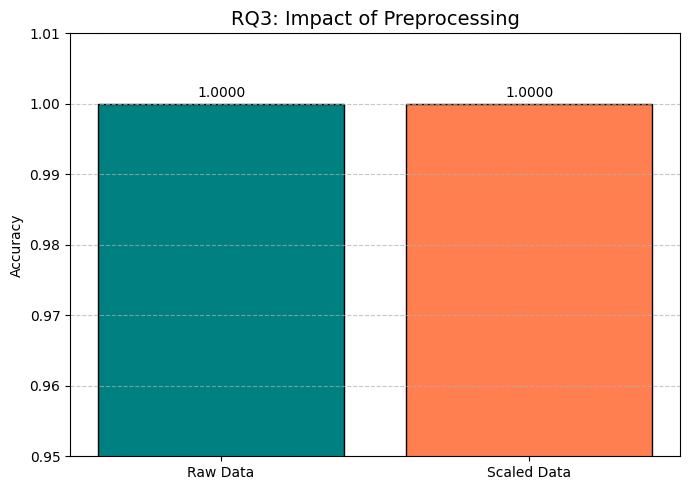


Figure Saved Successfully
C:\Users\dheer\Desktop\ML\RQ3_figure.pdf

RQ3 Completed Successfully


In [7]:
# ============================================
# RQ3: Impact of Preprocessing
# ============================================

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# --------------------------------------------
# Step 1: Load Dataset
# --------------------------------------------

df = pd.read_csv(
    r"C:\Users\dheer\Desktop\ML\cleaned_dataset.csv"
)

print("Dataset Loaded Successfully")
print("Dataset Shape:", df.shape)

# --------------------------------------------
# Step 2: Detect Target Column
# --------------------------------------------

target_col = None

for col in df.columns:
    if 'fraud' in col.lower():
        target_col = col
        break

print("Detected Target Column:", target_col)

if target_col is None:
    raise Exception("Fraud column not found")

# --------------------------------------------
# Step 3: Define Features and Target
# --------------------------------------------

y = df[target_col]
X = df.drop(columns=[target_col])

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)

# --------------------------------------------
# Step 4: Split Raw Data
# --------------------------------------------

X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# --------------------------------------------
# Step 5: Train on Raw Data
# --------------------------------------------

raw_model = RandomForestClassifier()

print("\nTraining on Raw Data...")

raw_model.fit(
    X_train_raw,
    y_train_raw
)

raw_predictions = raw_model.predict(
    X_test_raw
)

raw_accuracy = accuracy_score(
    y_test_raw,
    raw_predictions
)

# --------------------------------------------
# Step 6: Apply Standard Scaling
# --------------------------------------------

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# --------------------------------------------
# Step 7: Split Scaled Data
# --------------------------------------------

X_train_scaled, X_test_scaled, y_train_scaled, y_test_scaled = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)

# --------------------------------------------
# Step 8: Train on Scaled Data
# --------------------------------------------

scaled_model = RandomForestClassifier()

print("Training on Scaled Data...")

scaled_model.fit(
    X_train_scaled,
    y_train_scaled
)

scaled_predictions = scaled_model.predict(
    X_test_scaled
)

scaled_accuracy = accuracy_score(
    y_test_scaled,
    scaled_predictions
)

# --------------------------------------------
# Step 9: Create Results Table
# --------------------------------------------

results_df = pd.DataFrame({
    'Dataset Version': [
        'Raw Data',
        'Scaled Data'
    ],
    'Accuracy': [
        raw_accuracy,
        scaled_accuracy
    ]
})

results_df = results_df.round(4)

print("\nResults Table")
print(results_df)

# --------------------------------------------
# Step 10: Save Results Table
# --------------------------------------------

table_path = r"C:\Users\dheer\Desktop\ML\RQ3_table.csv"

results_df.to_csv(
    table_path,
    index=False
)

print("\nTable Saved Successfully")
print(table_path)

# --------------------------------------------
# Step 11: Create Figure
# --------------------------------------------

plt.figure(figsize=(7,5))

bars = plt.bar(
    results_df['Dataset Version'],
    results_df['Accuracy'],
    color=['teal', 'coral'],
    edgecolor='black'
)

# Add value labels
for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.001,
        f'{height:.4f}',
        ha='center',
        fontsize=10
    )

plt.title(
    'RQ3: Impact of Preprocessing',
    fontsize=14
)

plt.ylabel('Accuracy')

plt.ylim(0.95, 1.01)

plt.grid(
    axis='y',
    linestyle='--',
    alpha=0.7
)

plt.tight_layout()

# --------------------------------------------
# Step 12: Save Figure
# --------------------------------------------

figure_path = r"C:\Users\dheer\Desktop\ML\RQ3_figure.pdf"

plt.savefig(
    figure_path,
    bbox_inches='tight'
)

plt.show()

print("\nFigure Saved Successfully")
print(figure_path)

# --------------------------------------------
# Completed
# --------------------------------------------

print("\nRQ3 Completed Successfully")